In [176]:
import pandas as pd
from pandas import factorize

In [177]:
gas = pd.Series([1,2,3,4], index=['a','b','c','d'])
gas

a    1
b    2
c    3
d    4
dtype: int64

In [178]:
df = pd.DataFrame([['pera','peric', 23],['stepa','stepanovic']], columns=['ime','prezime','godiste'])

In [179]:
df.iloc[0,1]

'peric'

In [180]:
df[df['godiste'] > 23]

,ime,prezime,godiste


In [181]:
df

,ime,prezime,godiste
0,pera,peric,23.0
1,stepa,stepanovic,NaN


In [182]:
df.dropna()

,ime,prezime,godiste
0,pera,peric,23.0


In [183]:
df.fillna(0)

,ime,prezime,godiste
0,pera,peric,23.0
1,stepa,stepanovic,0.0


In [184]:
df.fillna(df['godiste'].mean())

,ime,prezime,godiste
0,pera,peric,23.0
1,stepa,stepanovic,23.0


In [185]:
df = pd.read_csv('data/iris.csv')


In [186]:
df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [187]:
df.describe()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [188]:
df.shape

(150, 5)

In [189]:
df.isna().any()

Sepal_Length    False
Sepal_Width     False
Petal_Length    False
Petal_Width     False
Species         False
dtype: bool

Koliko je koja kolona slicna kojoj

In [190]:
df.corr(numeric_only=True)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
Sepal_Length,1.000000,-0.117570,0.871754,0.817941
Sepal_Width,-0.117570,1.000000,-0.428440,-0.366126
Petal_Length,0.871754,-0.428440,1.000000,0.962865
Petal_Width,0.817941,-0.366126,0.962865,1.000000


Mozemo dropovati petal_lenght ili Petal_width jer su maltene iste (0.96 je korelacija)

In [191]:
y = df[['Species']]

In [192]:
feature_names = df.columns.to_list()[:-1]

In [193]:
X = df[feature_names]

In [194]:
X.shape

(150, 4)

In [195]:
y.shape

(150, 1)

In [196]:
from sklearn.model_selection import train_test_split

In [197]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12, stratify=y)

ovaj stritify znaci da hocemo da ostane ista raspodela kad podelimo skupove (uzimamo od svakog po malo)

In [198]:
from sklearn.tree import DecisionTreeClassifier

In [199]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [200]:
y_train_predict = model.predict(X_train)

In [201]:
from sklearn.metrics import confusion_matrix

In [202]:
confusion_matrix(y_train, y_train_predict)

array([[35,  0,  0],
       [ 0, 35,  0],
       [ 0,  0, 35]])

In [203]:
y_test_predict = model.predict(X_test)

In [204]:
confusion_matrix(y_test, y_test_predict)

array([[15,  0,  0],
       [ 0, 14,  1],
       [ 0,  0, 15]])

In [205]:
model.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [206]:
model.feature_importances_

array([0.01904762, 0.        , 0.55917367, 0.42177871])

In [207]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

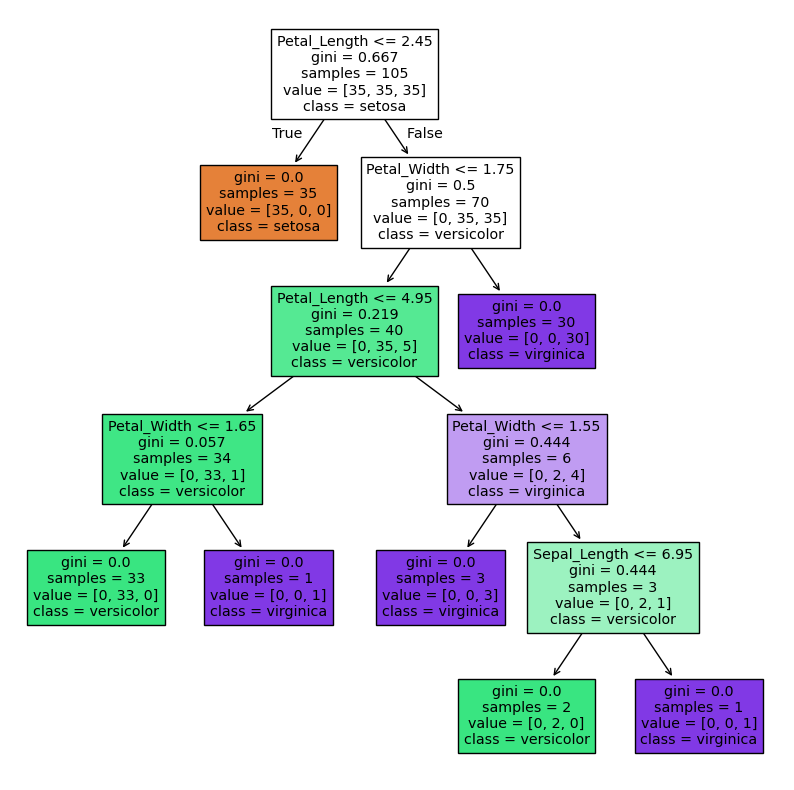

In [208]:
plt.figure(figsize=(10,10))
_ = plot_tree(model, feature_names=feature_names, class_names=model.classes_, filled=True)

In [209]:
from sklearn.model_selection import GridSearchCV

In [210]:
params = {'criterion': ['gini', 'entropy'],
            'max_depth': [2,3,4],
            'min_samples_leaf': [2,3]}

ovo cv je koliko imamo podela

In [211]:
model = GridSearchCV(DecisionTreeClassifier(), param_grid=params, scoring='accuracy', cv=5)

In [212]:
model.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 3]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [213]:
model.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [214]:
model.best_params_

{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2}

In [215]:
model.best_score_

np.float64(0.9333333333333333)

In [216]:
y_predict = model.best_estimator_.predict(X_test)

In [217]:
confusion_matrix(y_test, y_predict)

array([[15,  0,  0],
       [ 0, 14,  1],
       [ 0,  0, 15]])

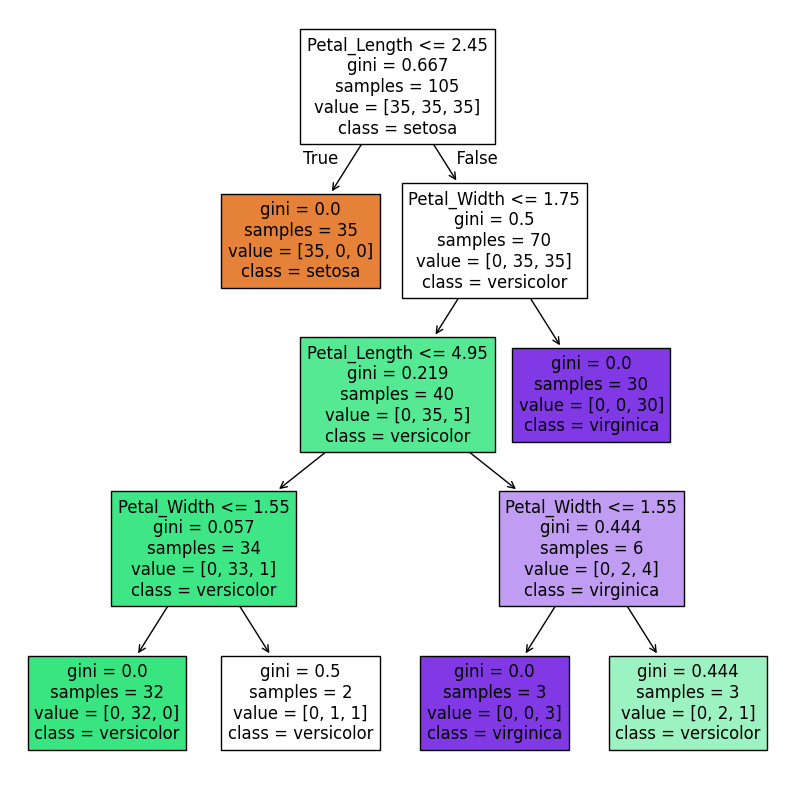

In [218]:
plt.figure(figsize=(10,10))
_ = plot_tree(model.best_estimator_, feature_names=feature_names, class_names=model.classes_, filled=True)

In [219]:
from sklearn.neighbors import KNeighborsClassifier

posto sada za ovu funkciju koristis rastojanje,moras da normalizujes podatke

In [253]:
model = KNeighborsClassifier()

In [221]:
model.fit(X_train, y_train)

D:\ip1 vezbe\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [252]:
y_pred = model.predict(X_test)

D:\ip1 vezbe\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


ValueError: X has 2 features, but KNeighborsClassifier is expecting 4 features as input.

In [223]:
confusion_matrix(y_test, y_pred)

array([[15,  0,  0],
       [ 0, 14,  1],
       [ 0,  0, 15]])

In [224]:
from sklearn.preprocessing import StandardScaler

In [256]:
X = df.iloc[:,:2]

In [257]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=89, stratify=y)

In [258]:
scaler = StandardScaler()

In [259]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


varijansa

In [260]:
scaler.var_

array([0.71583311, 0.18855692])

standardna devijacija (koren iz varijanse)

In [261]:
scaler.scale_

array([0.84606921, 0.43423141])

In [262]:
scaler.mean_

array([5.83619048, 3.02952381])

In [263]:
X_train = scaler.transform(X_train)

2 nacina za test skup

In [264]:
# 1
scaler_test = StandardScaler()
scaler_test.fit(X_test)

,copy,True
,with_mean,True
,with_std,True


In [265]:
scaler_test.mean_

array([5.86      , 3.12222222])

In [266]:
scaler_test.transform(X_test)

array([[-0.20660503, -0.51938417],
       [ 1.0846764 , -0.28566129],
       [ 0.69729197,  0.18178446],
       [-0.85224575, -0.98682992],
       [-0.98137389,  0.88295309],
       [ 1.47206083,  0.18178446],
       [ 0.56816383, -0.98682992],
       [-1.6270146 ,  1.11667596],
       [ 0.1807794 , -2.1554443 ],
       [-1.36875832, -0.05193842],
       [-0.46486132,  2.51901321],
       [-1.88527089, -0.51938417],
       [ 1.73031712, -0.28566129],
       [-1.11050203,  0.64923021],
       [ 1.34293269,  0.18178446],
       [ 0.82642012, -0.28566129],
       [ 1.34293269, -0.05193842],
       [-0.07747689, -1.22055279],
       [-1.11050203,  1.11667596],
       [ 1.21380455,  0.18178446],
       [-0.20660503,  1.58412171],
       [ 1.0846764 , -0.28566129],
       [ 0.43903569, -0.75310704],
       [ 0.69729197,  0.18178446],
       [ 0.1807794 ,  0.64923021],
       [-1.23963017,  1.11667596],
       [-1.36875832, -0.28566129],
       [ 0.30990754, -0.75310704],
       [-0.7231176 ,

ne koristiti 1. opciju

In [267]:
# 2
X_test = scaler.transform(X_test)

In [268]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [269]:
#param_gird = {'n_neigbours': range(2,7),
#              'weights': ['uniform', 'distance'],
#              }
#GridSearchCV(KNeighborsClassifier, param_grid= param_gird)

Sto je K manje to je jedinka vaznija,sto je k vece to su susedi vazniji

In [342]:
model = KNeighborsClassifier(n_neighbors=10)

In [343]:
model.fit(X_train, y_train)

D:\ip1 vezbe\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [344]:
y_train_pred = model.predict(X_train)

In [345]:
confusion_matrix(y_train, y_train_pred)

array([[34,  1,  0],
       [ 0, 30,  5],
       [ 0, 15, 20]])

In [346]:
y_test_pred = model.predict(X_test)

In [347]:
confusion_matrix(y_test, y_test_pred)

array([[15,  0,  0],
       [ 0,  9,  6],
       [ 0,  7,  8]])

In [348]:
X_train[:,0].min()

np.float64(-1.8156794499548532)

In [349]:
y, y_index = pd.factorize(y)

In [350]:
X_min, X_max = X_train[:,0].min(), X_train[:,0].max()
y_min, y_max = X_train[:,1].min(), X_train[:,1].max()

In [351]:
step = 0.02

In [352]:
import numpy as np

In [353]:
x_range = np.arange(X_min, X_max, step)
y_range = np.arange(y_min, y_max, step)

ovo sledece kostistimo sad i vise nikad :)))

In [354]:
xx, yy = np.meshgrid(x_range, y_range)

ovo iznad su matrice a nama trebaju vektori pa sl funkcija poravnava matricu u vektor

In [355]:
x_column = xx.ravel()
y_column = yy.ravel()

In [356]:
both_columns = np.c_[x_column, y_column]
both_columns.shape

(54102, 2)

In [357]:
predicted_classes = model.predict(both_columns)

In [358]:
predicted_classes.reshape(xx.shape)

array([['versicolor', 'versicolor', 'versicolor', ..., 'virginica',
        'virginica', 'virginica'],
       ['versicolor', 'versicolor', 'versicolor', ..., 'virginica',
        'virginica', 'virginica'],
       ['versicolor', 'versicolor', 'versicolor', ..., 'virginica',
        'virginica', 'virginica'],
       ...,
       ['setosa', 'setosa', 'setosa', ..., 'virginica', 'virginica',
        'virginica'],
       ['setosa', 'setosa', 'setosa', ..., 'virginica', 'virginica',
        'virginica'],
       ['setosa', 'setosa', 'setosa', ..., 'virginica', 'virginica',
        'virginica']], shape=(254, 213), dtype=object)

In [359]:
from matplotlib.colors import ListedColormap

D:\ip1 vezbe\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


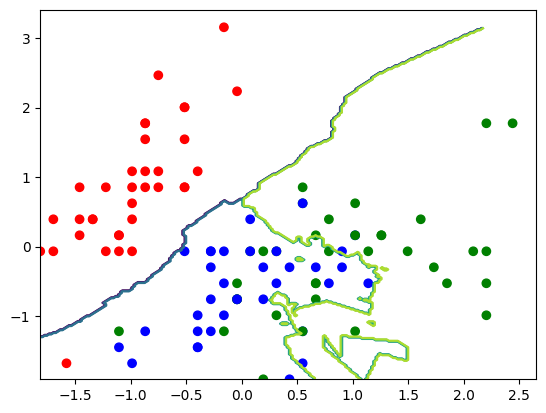

In [360]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_num = le.fit_transform(y_train)

predicted_numeric = le.transform(predicted_classes)

Z = predicted_numeric.reshape(xx.shape)

plt.contour(xx, yy, Z)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train_num, cmap=ListedColormap(['red', 'blue', 'green']))